In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm

In [ ]:
# 配置参数
BATCH_SIZE = 128
EPOCHS = 20
TEMPERATURE = 1
ALPHA = 0.3
NUM_CLASSES = 10
NUM_SAMPLES_TO_SHOW = 5  # 每个类别显示的示例数量

# 一、数据准备

In [ ]:
def prepare_data():
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4), 
        transforms.RandomHorizontalFlip(), # 数据增强策略
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    # 加载数据集
    train_set = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=False, transform=transform_train)
    test_set = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=False, transform=transform_test)
    
    # 可视化数据示例
    #visualize_samples(train_set, "Training Samples")
    
    return train_set, test_set

## 数据可视化

In [ ]:
def visualize_samples(dataset, title):
    classes = ('plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck')
    
    # 收集每个类别的样本
    class_samples = {i: [] for i in range(10)}
    for idx in range(len(dataset)):
        img, label = dataset[idx]
        if len(class_samples[label]) < NUM_SAMPLES_TO_SHOW:
            class_samples[label].append(img)
    
    # 绘制可视化网格
    plt.figure(figsize=(15, 8))
    for cls in range(10):
        for j in range(NUM_SAMPLES_TO_SHOW):
            ax = plt.subplot(10, NUM_SAMPLES_TO_SHOW, cls*NUM_SAMPLES_TO_SHOW + j + 1)
            img = class_samples[cls][j].numpy().transpose((1, 2, 0))
            img = img * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])
            plt.imshow(np.clip(img, 0, 1))
            ax.set_title(classes[cls] if j == 0 else "")
            ax.axis('off')
    plt.suptitle(title)
    #plt.savefig("data_samples.png", dpi=150)
    plt.close()

# 二、定义模型

In [ ]:
# 模型定义
class Teacher(nn.Module):
    def __init__(self):
        super(Teacher, self).__init__()
        self.net = torchvision.models.resnet18(pretrained=False)
        # 调整输入通道数
        self.net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.net.fc = nn.Linear(512, 10)  # CIFAR-10有10个类别

    def forward(self, x):
        return self.net(x)

In [152]:
class Student(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32, NUM_CLASSES)
        )
    
    def forward(self, x):
        return self.model(x)


# 三、模型评估

In [109]:
# 评估与可视化
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


# 四、训练

## 1.教师模型训练

In [ ]:
# 训练流程
def train_teacher(model, train_loader, test_loader):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
    
    best_acc = 0.0
    history = {'train_loss': [], 'val_acc': []}
    
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        
        with tqdm(train_loader, unit="batch", desc=f"Teacher Epoch {epoch+1}/{EPOCHS}") as pbar:
            for images, labels in pbar:
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
        # 验证
        val_acc = evaluate(model, test_loader)
        scheduler.step()
        
        history['train_loss'].append(total_loss/len(train_loader))
        history['val_acc'].append(val_acc)
        
        # 保存最佳模型
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "models/best_teacher.pth")
        
        print(f"Epoch {epoch+1}: Val Acc {val_acc:.2f}%")
    
    return history

## 2.知识蒸馏过程

In [153]:
def distill(student, teacher, train_loader, test_loader):
    student.train()
    teacher.eval()
    
    criterion = nn.KLDivLoss(reduction='batchmean')
    optimizer = optim.AdamW(student.parameters(), lr=1e-3)
    best_acc = 0.0
    history = {'loss': [], 'acc': []}
    
    for epoch in range(EPOCHS):
        total_loss = 0.0
        correct = 0
        total = 0
        with tqdm(train_loader, unit="batch", desc=f"Distill Epoch {epoch+1}/{EPOCHS}") as pbar:
            for images, labels in pbar:
                optimizer.zero_grad()
                
                with torch.no_grad():
                    teacher_logits = teacher(images)
                
                student_logits = student(images)
                
                # 蒸馏损失
                loss_distill = criterion(
                    torch.log_softmax(student_logits/TEMPERATURE, dim=1),
                    torch.softmax(teacher_logits/TEMPERATURE, dim=1)
                ) * (TEMPERATURE**2)
                
                # 交叉熵损失
                loss_ce = nn.CrossEntropyLoss()(student_logits, labels)
                loss = ALPHA*loss_distill + (1-ALPHA)*loss_ce  #总损失
                
                loss.backward()
                optimizer.step()
                
                # 统计指标
                total_loss += loss.item()
                _, predicted = torch.max(student_logits, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
                
                pbar.set_postfix({
                    'loss': f"{loss.item():.4f}",
                    'acc': f"{100*correct/total:.2f}%"
                })
        
        # 验证
        val_acc = evaluate(student, test_loader)
        history['loss'].append(total_loss/len(train_loader))
        history['acc'].append(val_acc)
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(student.state_dict(), "models/best_student.pth")
        
        print(f"Epoch {epoch+1}: Val Acc {val_acc:.2f}%")
    
    return history

# 五、可视化

In [121]:
def visualize_results(teacher_hist, student_hist):
    plt.figure(figsize=(15, 5))
    
    # 教师训练曲线
    plt.subplot(1, 2, 1)
    plt.plot(teacher_hist['train_loss'], label='Teacher Loss')
    plt.plot(teacher_hist['val_acc'], label='Teacher Acc')
    plt.title("Teacher Training Process")
    plt.xlabel("Epoch")
    plt.legend()
    
    # 学生训练曲线
    plt.subplot(1, 2, 2)
    plt.plot(student_hist['loss'], label='Student Loss')
    plt.plot(student_hist['acc'], label='Student Acc')
    plt.title("Student Distillation Process")
    plt.xlabel("Epoch")
    plt.legend()
    
    #plt.savefig("training_curves.png", dpi=150)
    plt.show()

In [112]:
def generate_report(model, loader, classes):
    model.eval()
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.numpy())
    
    # 分类报告
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # 混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    #plt.savefig("confusion_matrix.png", dpi=150)
    plt.close()


# 六、主函数调用

In [55]:
train_set, test_set = prepare_data()
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    
# 实验1：单独训练教师模型
print("\n=== Training Teacher ===")
teacher = Teacher()
teacher_hist = train_teacher(teacher, train_loader, test_loader)


=== Training Teacher ===


Teacher Epoch 1/10: 100%|██████████| 391/391 [07:34<00:00,  1.16s/batch, loss=1.0513]


Epoch 1: Val Acc 59.47%


Teacher Epoch 2/10: 100%|██████████| 391/391 [07:35<00:00,  1.17s/batch, loss=0.7826]


Epoch 2: Val Acc 72.97%


...

Epoch 8: Val Acc 83.63%


Teacher Epoch 9/10: 100%|██████████| 391/391 [11:53<00:00,  1.83s/batch, loss=0.6336]


Epoch 9: Val Acc 77.93%


Teacher Epoch 10/10: 100%|██████████| 391/391 [14:12<00:00,  2.18s/batch, loss=0.5489]


Epoch 10: Val Acc 83.68%


In [154]:
# 实验2：知识蒸馏训练学生
print("\n=== Distilling Student ===")
teacher.load_state_dict(torch.load("models/best_teacher.pth"))
student = Student()
student_hist = distill(student, teacher, train_loader, test_loader)


=== Distilling Student ===


Distill Epoch 1/20: 100%|██████████| 391/391 [01:47<00:00,  3.64batch/s, loss=1.7299, acc=27.35%]


Epoch 1: Val Acc 30.78%


Distill Epoch 2/20: 100%|██████████| 391/391 [03:01<00:00,  2.15batch/s, loss=1.6743, acc=34.24%]


Epoch 2: Val Acc 34.79%


...

Epoch 18: Val Acc 51.31%


Distill Epoch 19/20: 100%|██████████| 391/391 [01:36<00:00,  4.04batch/s, loss=1.0663, acc=51.58%]


Epoch 19: Val Acc 51.19%


Distill Epoch 20/20: 100%|██████████| 391/391 [01:38<00:00,  3.99batch/s, loss=1.4514, acc=51.66%]


Epoch 20: Val Acc 50.84%


# 调用之前记得把路径换一个！！！！！！

In [88]:
# 实验3：直接训练学生模型（对比基准）
print("\n=== Training Student Directly ===")
baseline_student = Student()
baseline_hist = train_teacher(baseline_student, train_loader, test_loader)


=== Training Student Directly ===


Teacher Epoch 1/20: 100%|██████████| 391/391 [00:18<00:00, 21.49batch/s, loss=1.8357]


Epoch 1: Val Acc 31.55%


Teacher Epoch 2/20: 100%|██████████| 391/391 [00:17<00:00, 22.51batch/s, loss=1.5705]


Epoch 2: Val Acc 34.68%


...

Epoch 18: Val Acc 50.65%


Teacher Epoch 19/20: 100%|██████████| 391/391 [00:52<00:00,  7.51batch/s, loss=1.4353]


Epoch 19: Val Acc 50.65%


Teacher Epoch 20/20: 100%|██████████| 391/391 [00:51<00:00,  7.62batch/s, loss=1.3627]


Epoch 20: Val Acc 51.07%


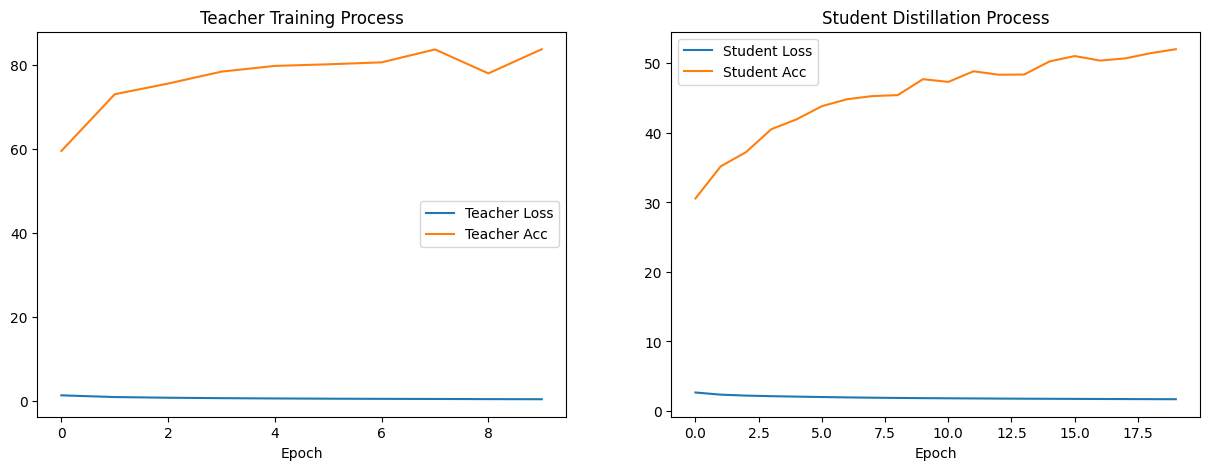


=== Teacher Performance ===

Classification Report:
              precision    recall  f1-score   support

    airplane       0.81      0.87      0.84      1000
  automobile       0.88      0.95      0.92      1000
        bird       0.73      0.86      0.79      1000
         cat       0.68      0.74      0.71      1000
        deer       0.82      0.85      0.83      1000
         dog       0.90      0.64      0.75      1000
        frog       0.85      0.90      0.87      1000
       horse       0.88      0.86      0.87      1000
        ship       0.93      0.90      0.91      1000
       truck       0.95      0.80      0.87      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000


=== Distilled Student Performance ===

Classification Report:
              precision    recall  f1-score   support

    airplane       0.53      0.51      0.52      1000
  automobile    

In [150]:
# 可视化对比结果
visualize_results(teacher_hist, student_hist)
    
# 生成最终报告
classes = test_set.classes
print("\n=== Teacher Performance ===")
generate_report(teacher, test_loader, classes)
print("\n=== Distilled Student Performance ===")
generate_report(student, test_loader, classes)
print("\n=== Baseline Student Performance ===")
generate_report(baseline_student, test_loader, classes)

# 七、结果分析

## 1.单图预测

In [ ]:
# 图像预处理管道（和测试集处理保持一致）
def get_test_transform():
    return transforms.Compose([
        transforms.Resize((32, 32)),      
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2023, 0.1994, 0.2010]
        )
    ])

In [ ]:
from PIL import Image
def predict_single_image(model, img_path):
    
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
    
    # 预处理图像
    transform = get_test_transform()
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0)  # 添加batch维度
    
    # 执行预测
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        pred_class = torch.argmax(probabilities).item()
    
    # 可视化结果
    plt.figure(figsize=(10, 5))
    
    # 显示原始图像
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')
    
    # 显示预测概率
    plt.subplot(1, 2, 2)
    plt.barh(class_names, probabilities.numpy())
    plt.title(f"Prediction: {class_names[pred_class]}")
    plt.xlabel("Probability")
    plt.tight_layout()
    plt.show()
    
    return class_names[pred_class]

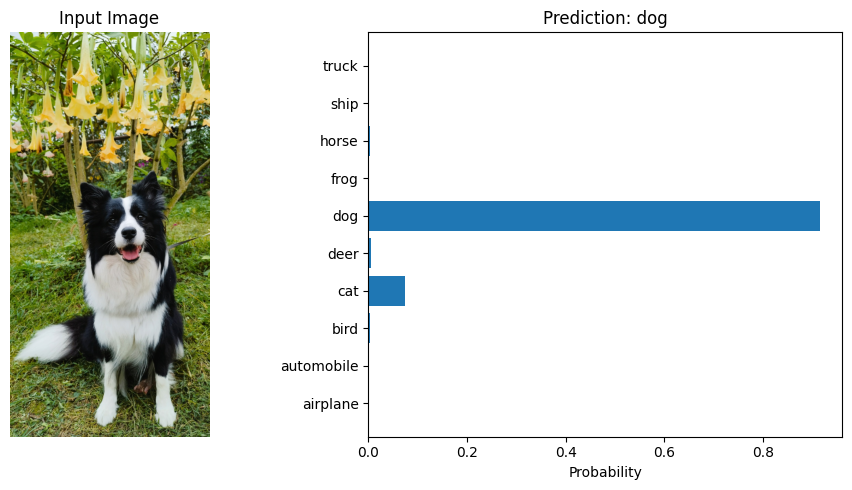

最终预测结果: dog


In [146]:
img_path = "data\dog.jpg"  # 图片相对路径
prediction = predict_single_image(teacher, img_path)
print(f"最终预测结果: {prediction}")

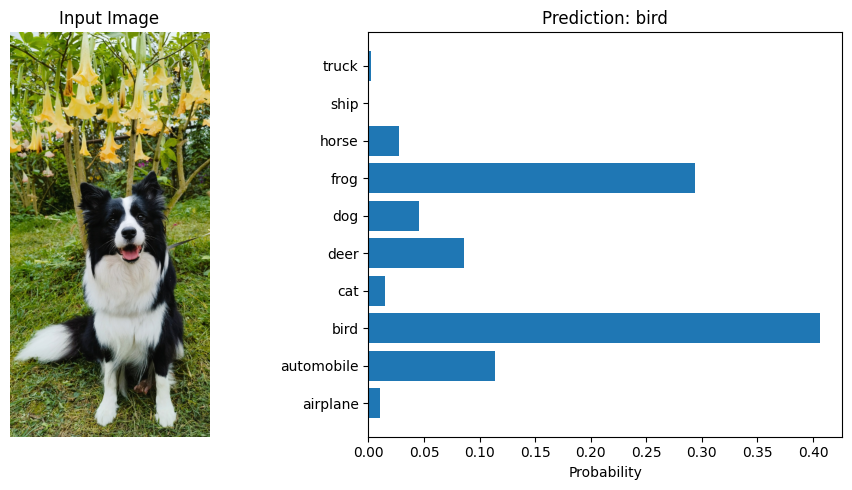

最终预测结果: bird


In [145]:
img_path = "data\dog.jpg"  # 图片相对路径
prediction = predict_single_image(student, img_path)
print(f"最终预测结果: {prediction}")

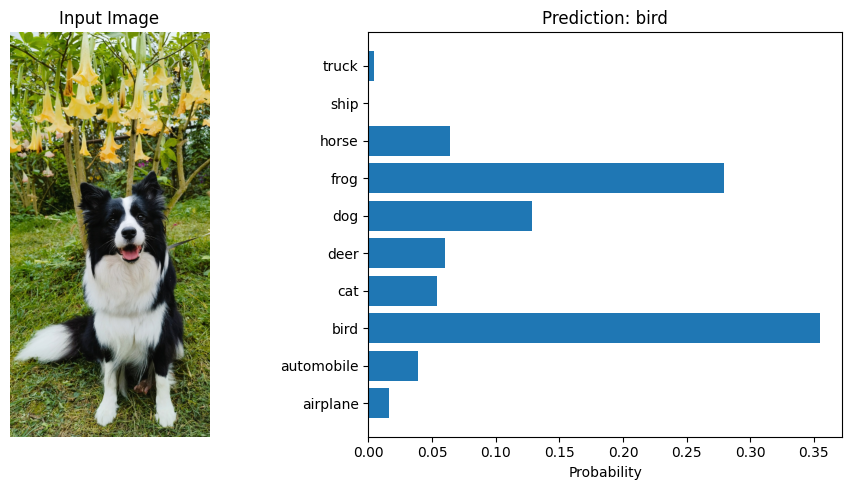

最终预测结果: bird


In [135]:
img_path = "data\dog.jpg"  # 图片相对路径
prediction = predict_single_image(baseline_student, img_path)
print(f"最终预测结果: {prediction}")

## 2.训练过程可视化

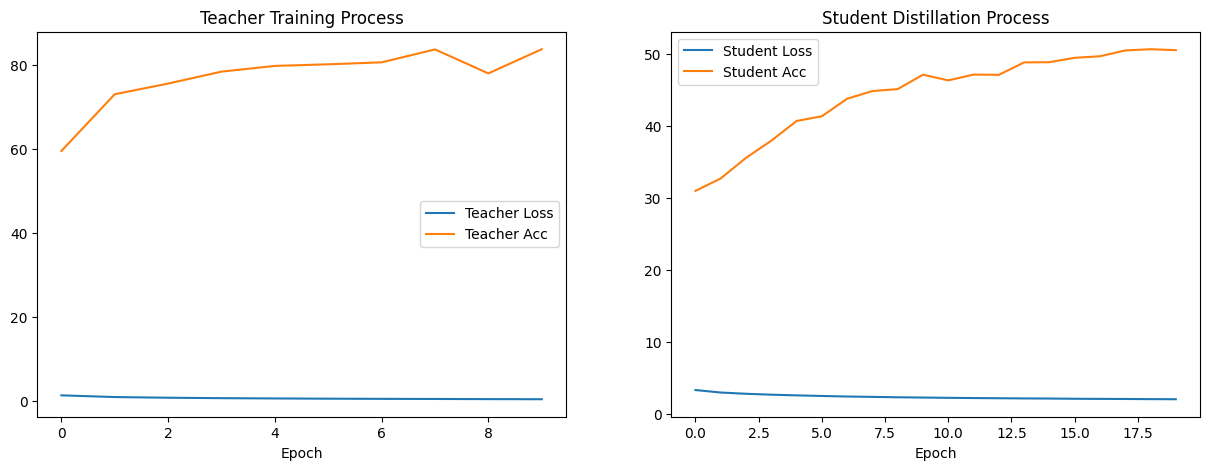

In [122]:
visualize_results(teacher_hist, student_hist)

## 3.错误分类实例

In [136]:
def analyze_misclassified(model, test_loader, class_names, num_samples=9):
    model.eval()
    misclassified = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            # 收集错误样本
            mask = (preds != labels)
            misclassified.extend([
                (images[i], labels[i], preds[i]) 
                for i in range(len(labels)) if mask[i]
            ])
            
            if len(misclassified) >= num_samples:
                break
    
    # 可视化展示
    plt.figure(figsize=(12, 12))
    for idx in range(min(num_samples, len(misclassified))):
        img, true_label, pred_label = misclassified[idx]
        
        # 反归一化处理
        img = img.numpy().transpose((1, 2, 0))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.subplot(3, 3, idx+1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

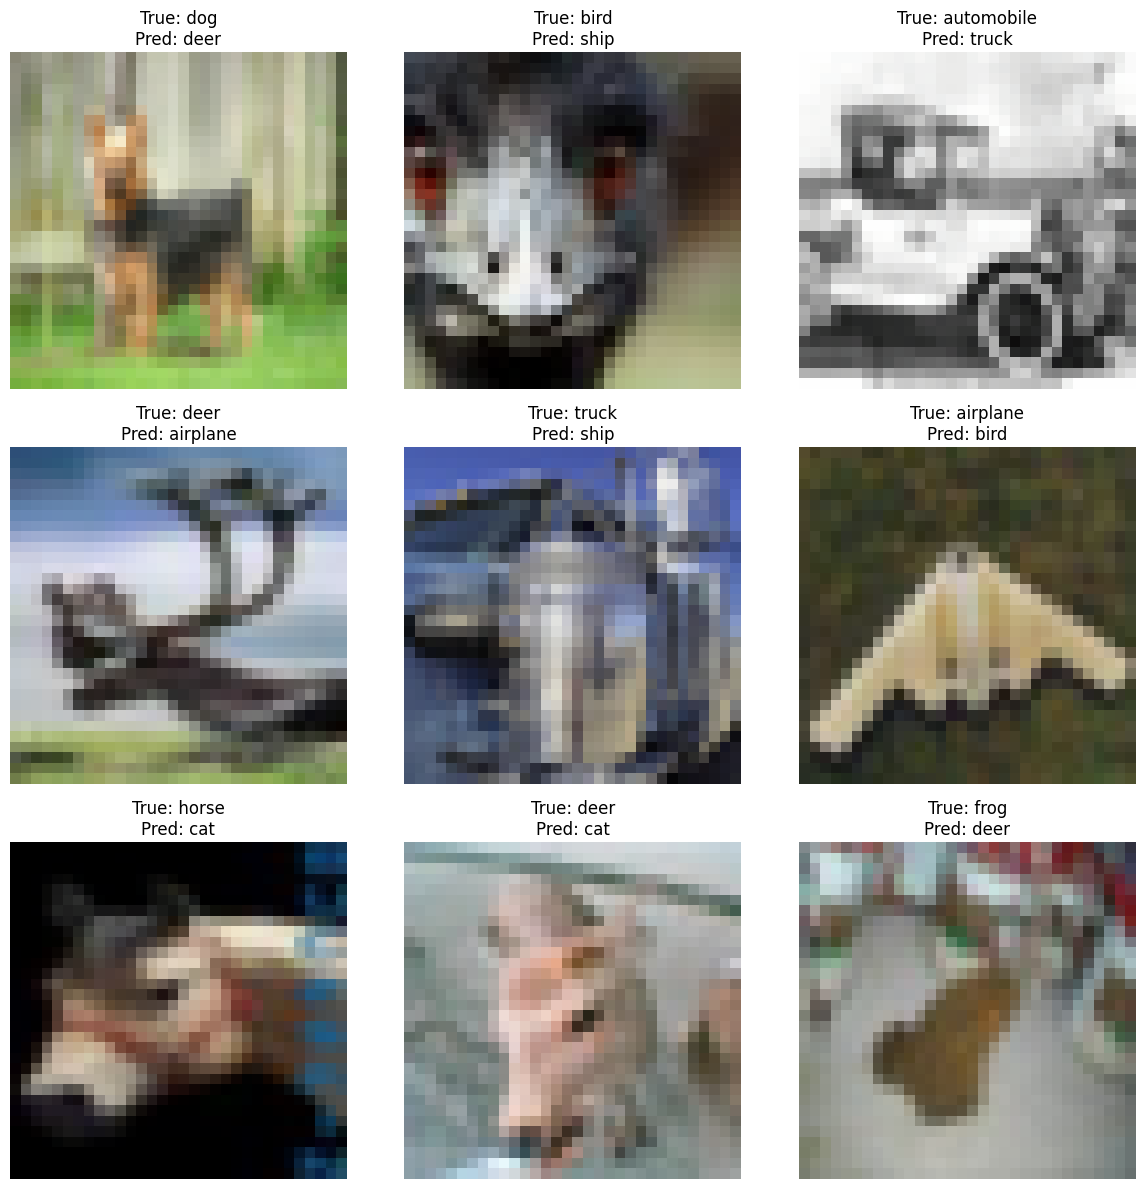

In [138]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
analyze_misclassified(teacher, test_loader, class_names, num_samples=9)

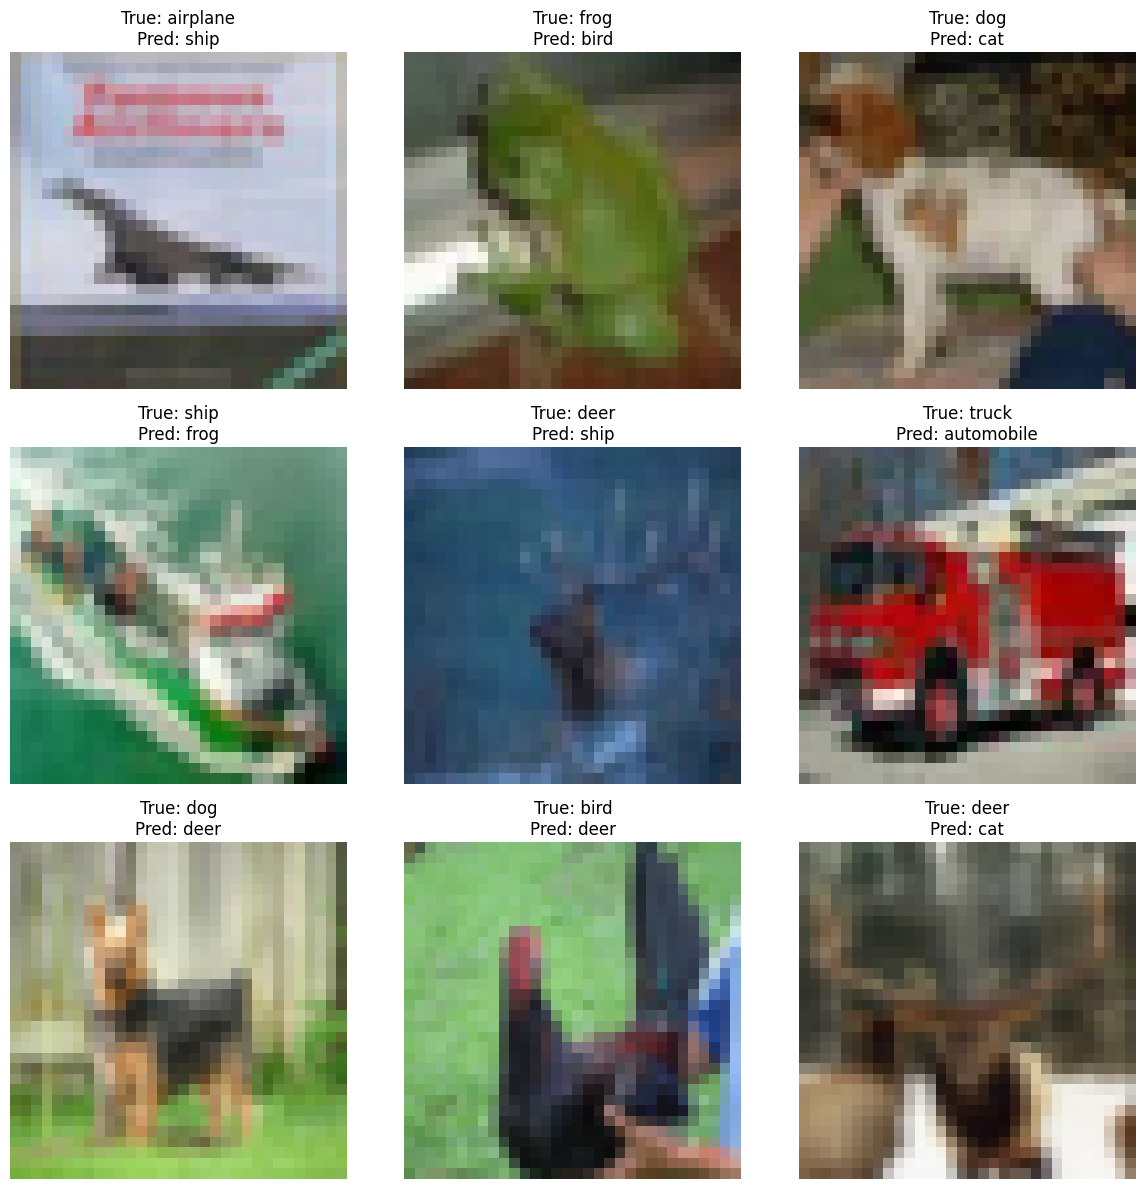

In [155]:
analyze_misclassified(student, test_loader, class_names, num_samples=9)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000234FFB3B1C0>
Traceback (most recent call last):
  File "d:\anaconda\envs\cpu-pytorch\lib\site-packages\torch\utils\data\dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "d:\anaconda\envs\cpu-pytorch\lib\site-packages\torch\utils\data\dataloader.py", line 1621, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000234FFB3B1C0>
Traceback (most recent call last):
  File "d:\anaconda\envs\cpu-pytorch\lib\site-packages\torch\utils\data\dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "d:\anaconda\envs\cpu-pytorch\lib\site-packages\torch\utils\data\dataloader.py", line 1621, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id

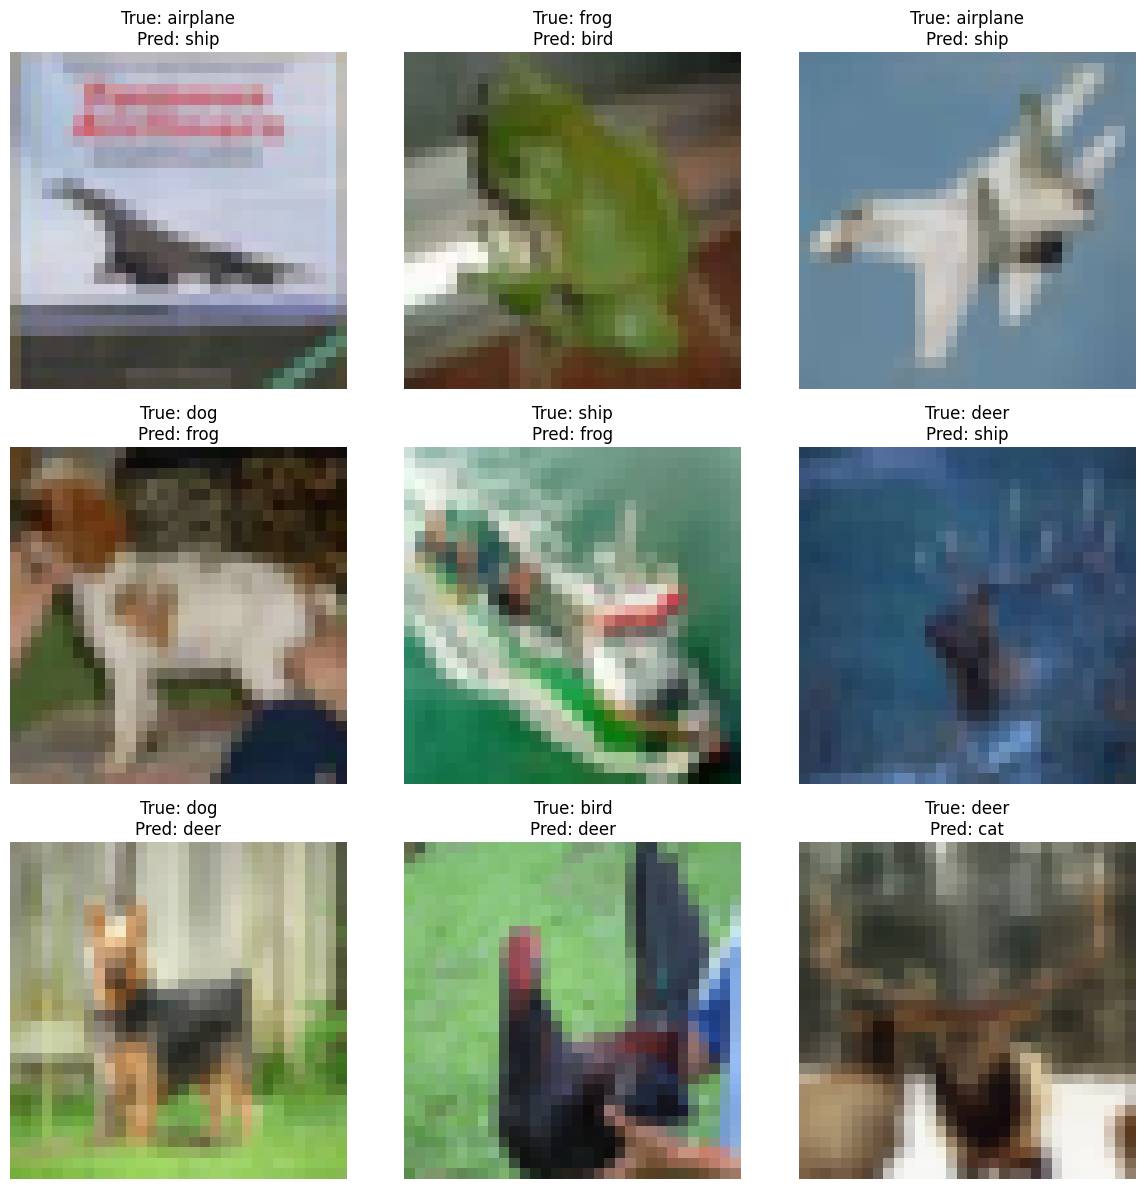

In [139]:
analyze_misclassified(baseline_student, test_loader, class_names, num_samples=9)